In [2]:
!pip install -q ultralytics
import torch
from ultralytics import YOLO
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
Device: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile, os, yaml

# Adjust ZIP_PATH if you uploaded to a folder inside Drive
ZIP_PATH = '/content/drive/MyDrive/yolo_ready.zip'

# Extract
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall('/content/')

# Fix data.yaml path to point to Colab location
yaml_path = '/content/yolo_ready/data.yaml'
with open(yaml_path) as f:
    cfg = yaml.safe_load(f)
cfg['path'] = '/content/yolo_ready'
with open(yaml_path, 'w') as f:
    yaml.safe_dump(cfg, f)

print('✓ Dataset extracted')
print('Classes:', cfg['names'])
print('Number of classes:', cfg['nc'])

# Verify structure
for split in ['train', 'valid']:
    img_dir = f'/content/yolo_ready/images/{split}'
    lbl_dir = f'/content/yolo_ready/labels/{split}'
    if os.path.exists(img_dir):
        print(f'  {split}: {len(os.listdir(img_dir))} images, {len(os.listdir(lbl_dir))} labels')

✓ Dataset extracted
Classes: ['Pothole', 'Traffic_Light', 'Waste_Container']
Number of classes: 3
  train: 1199 images, 1199 labels
  valid: 301 images, 301 labels


In [5]:
from ultralytics import YOLO

model = YOLO('yolov8m.pt')
results = model.train(
    data='/content/yolo_ready/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    patience=25,
    name='smart_city_final'
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_ready/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=smart_city_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

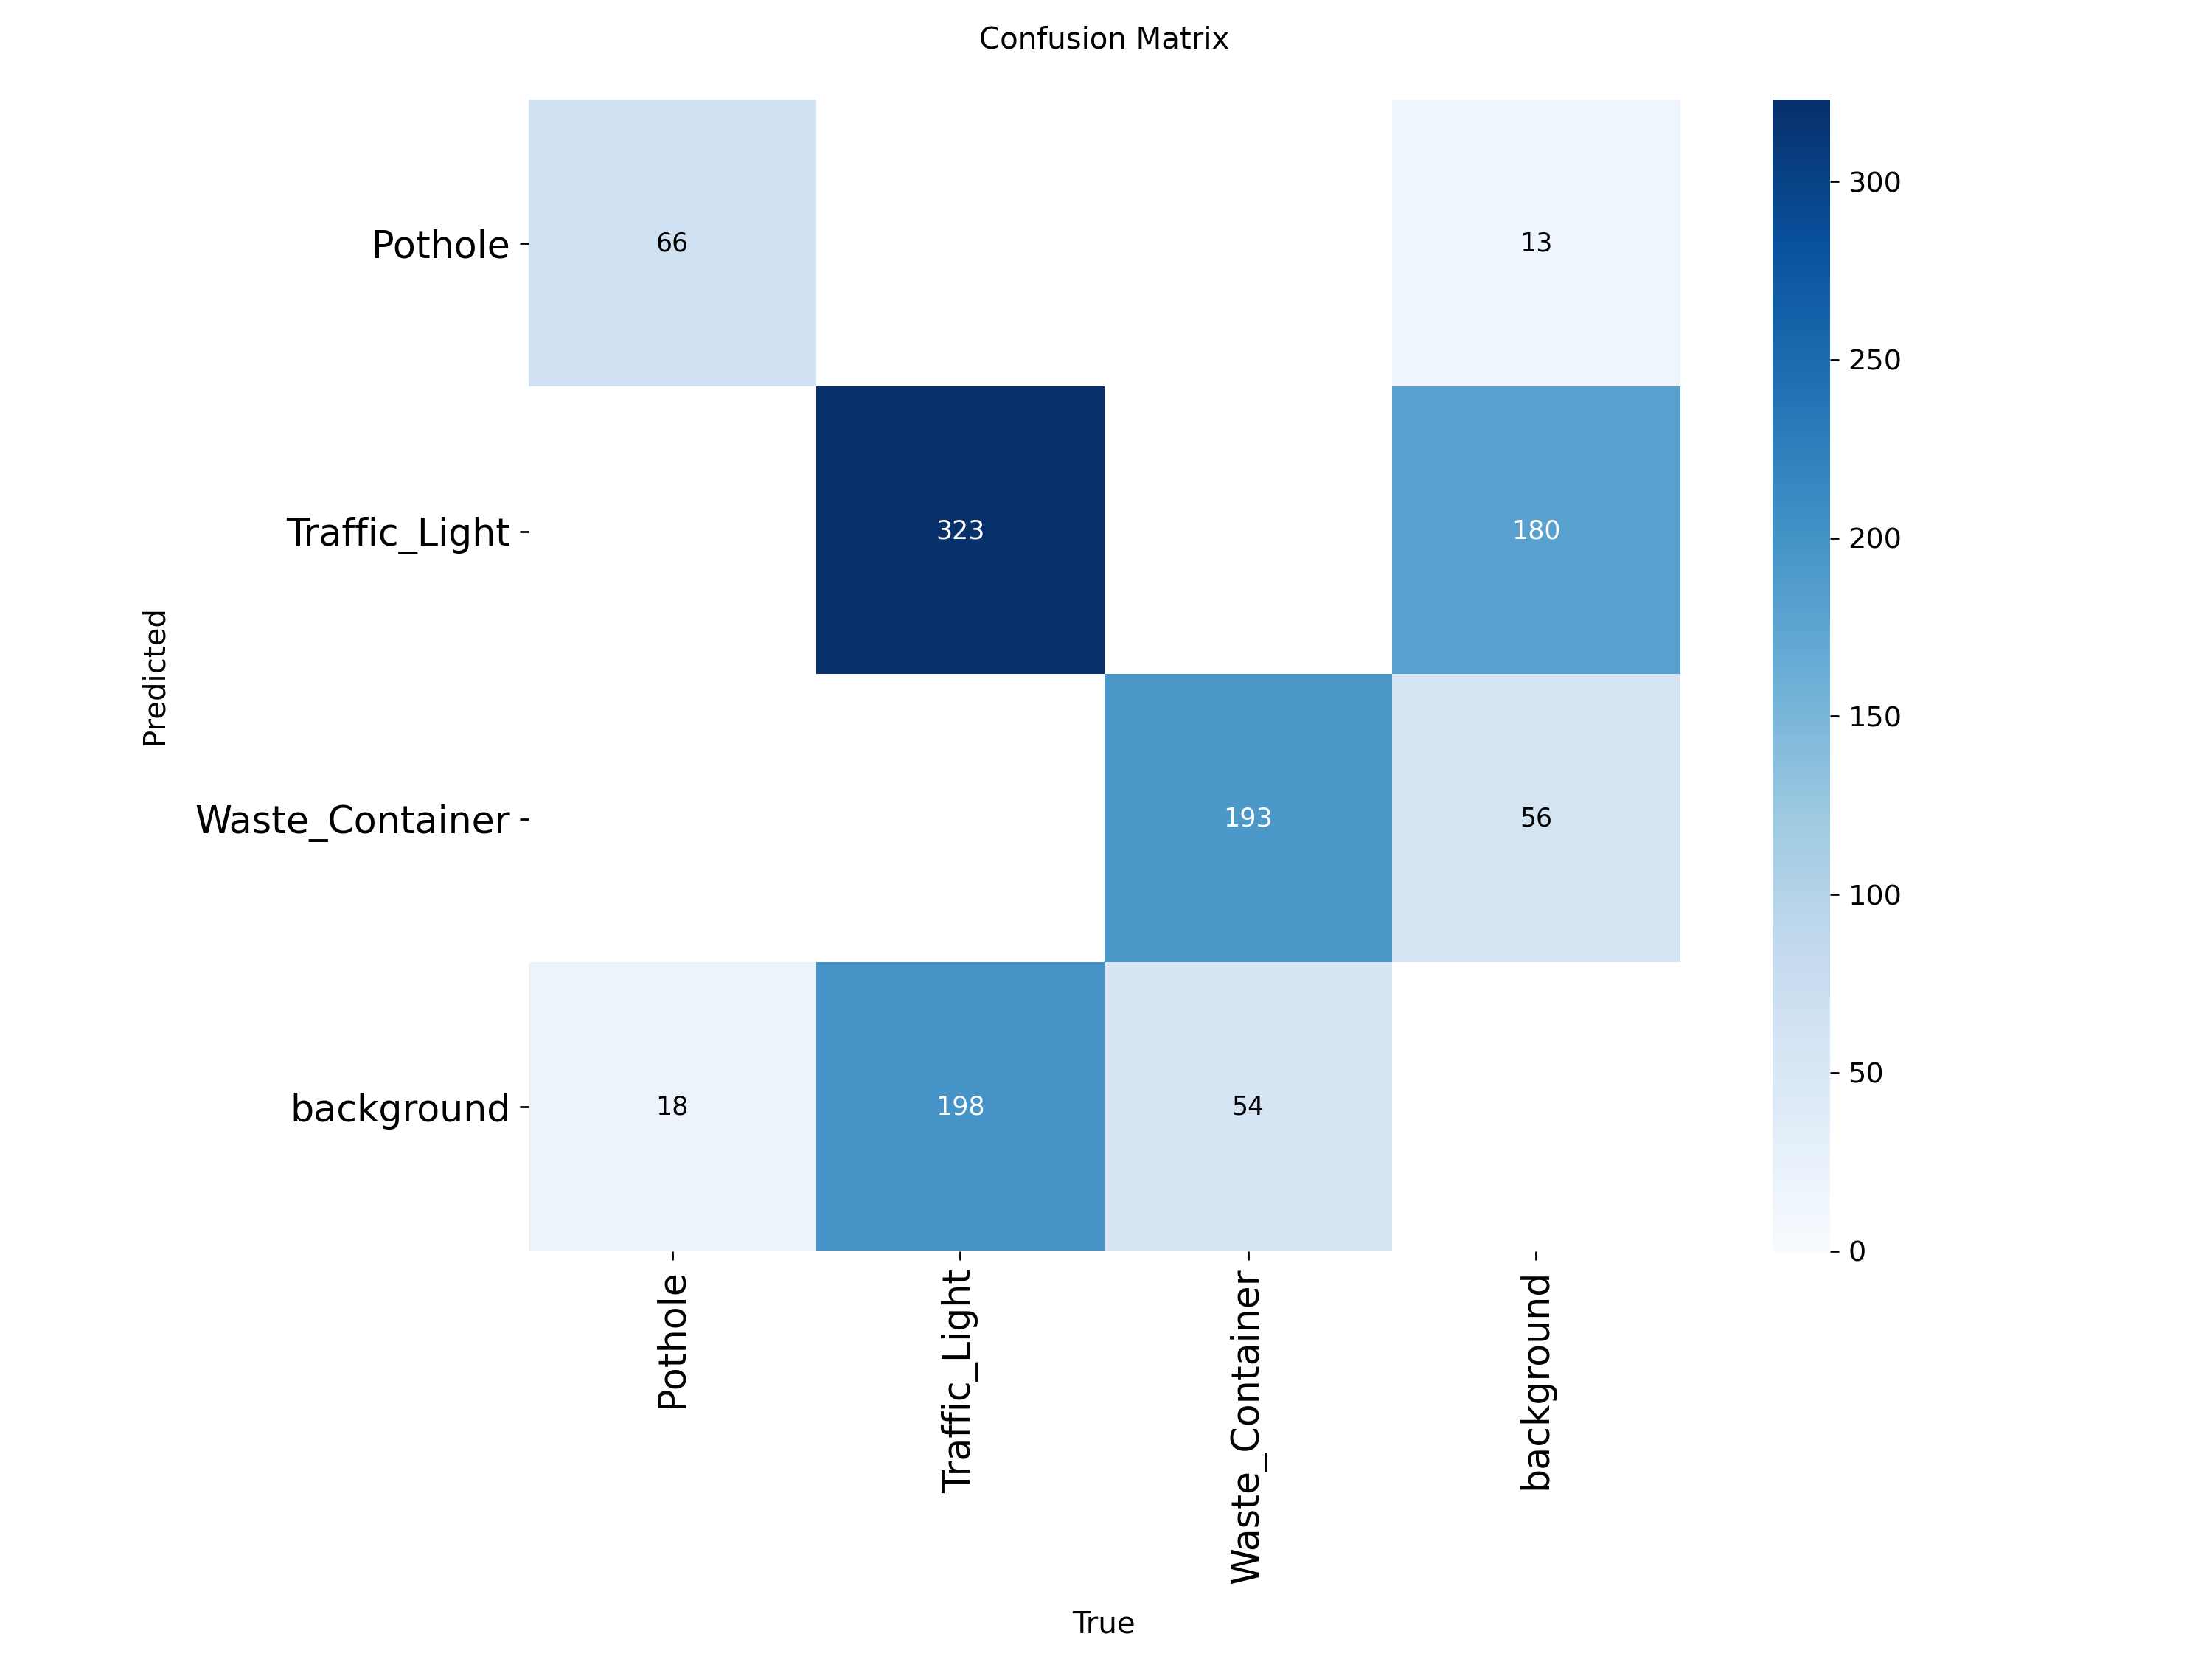

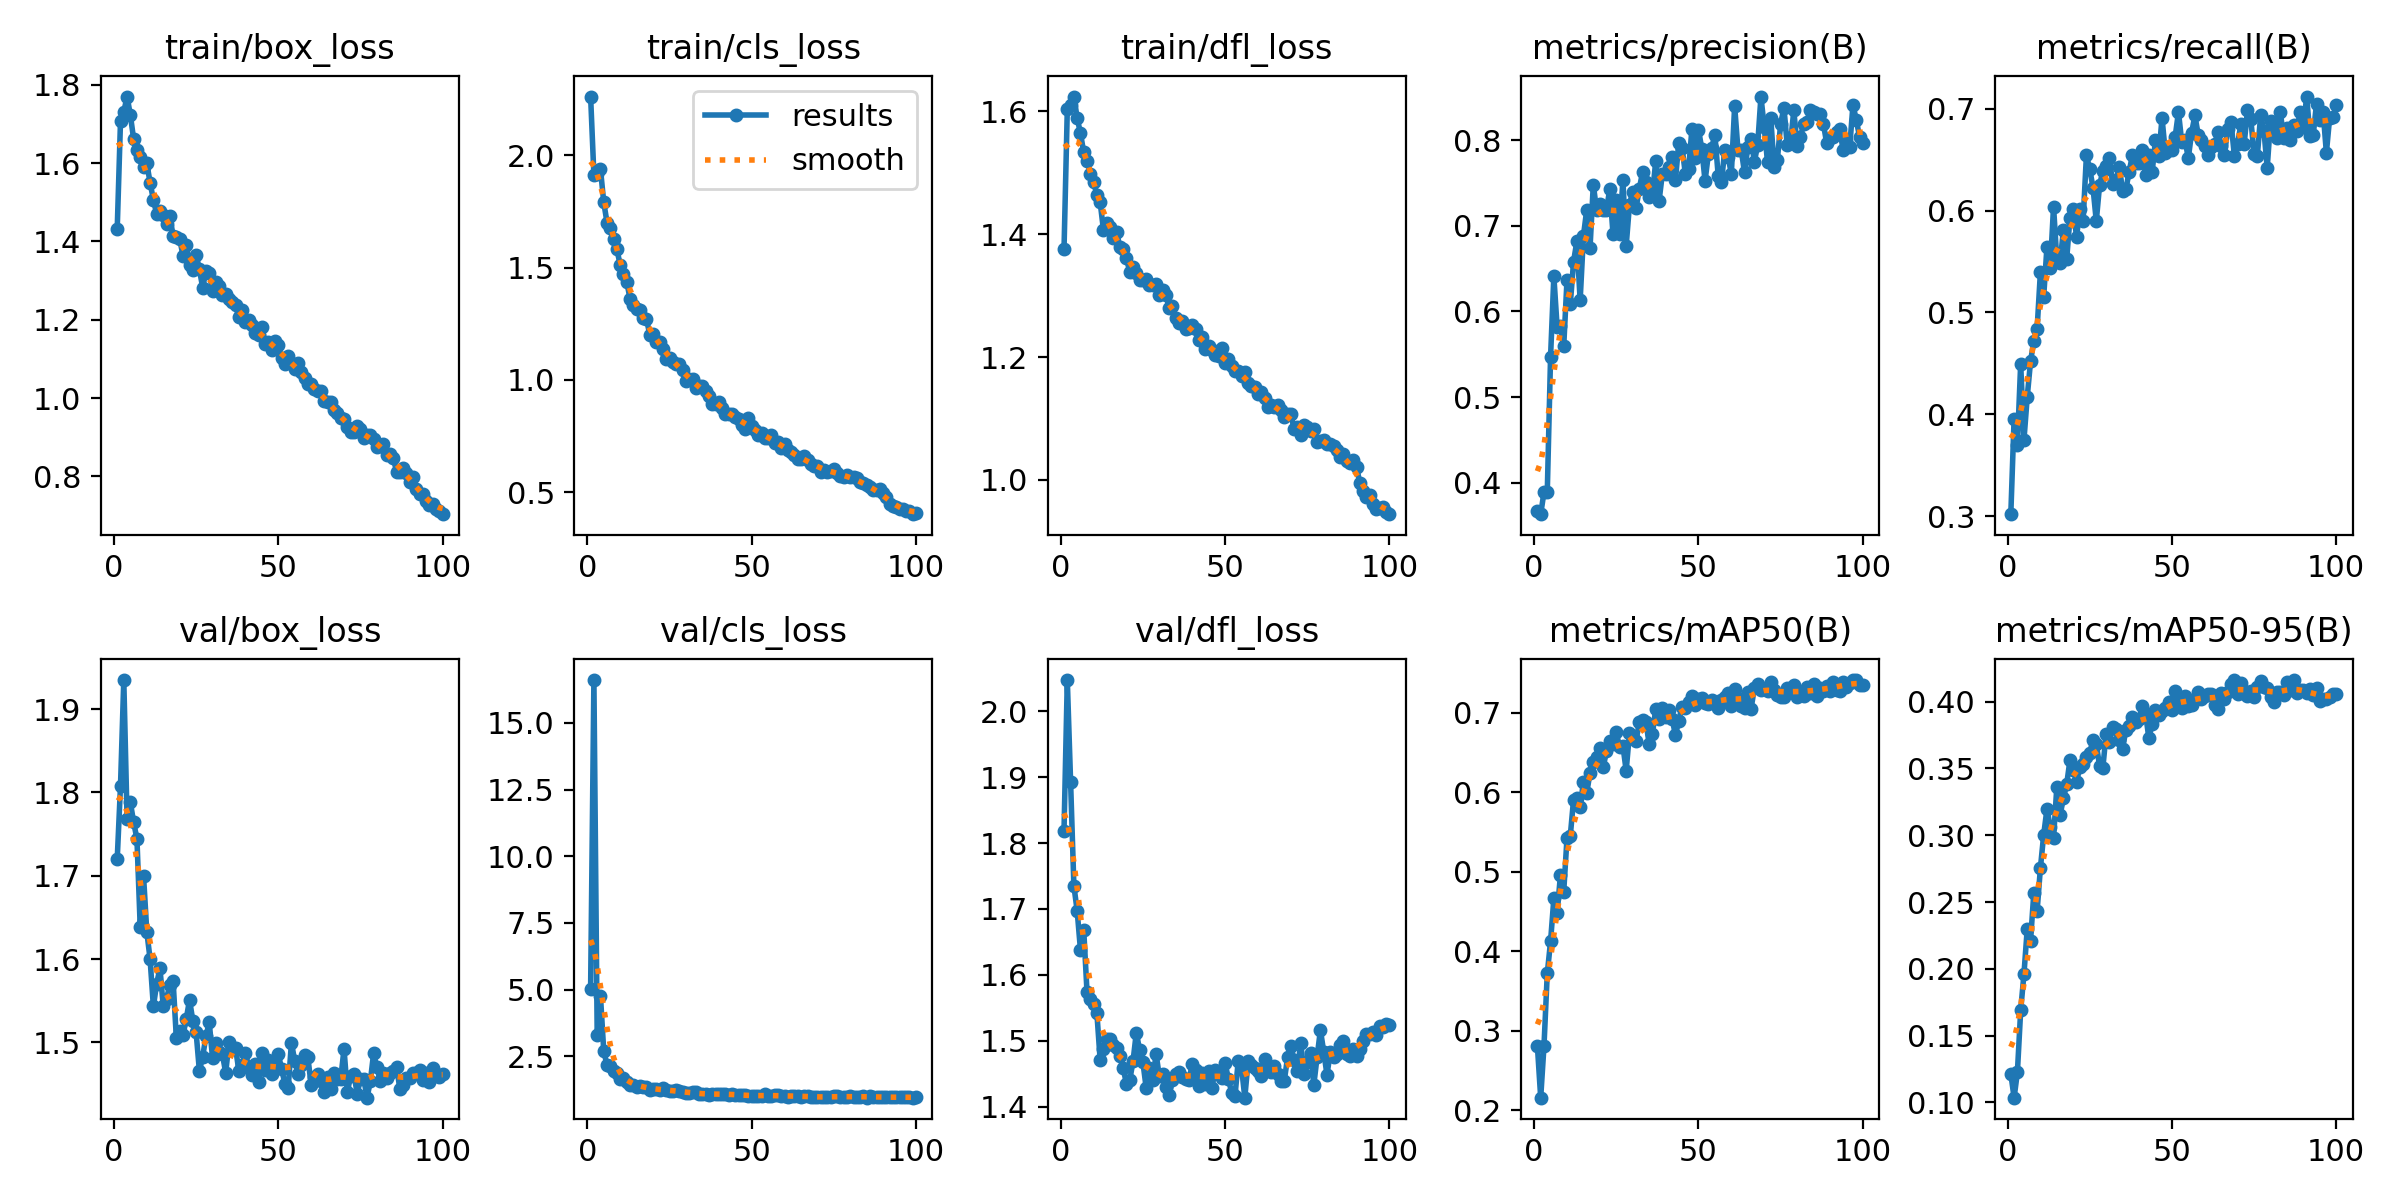

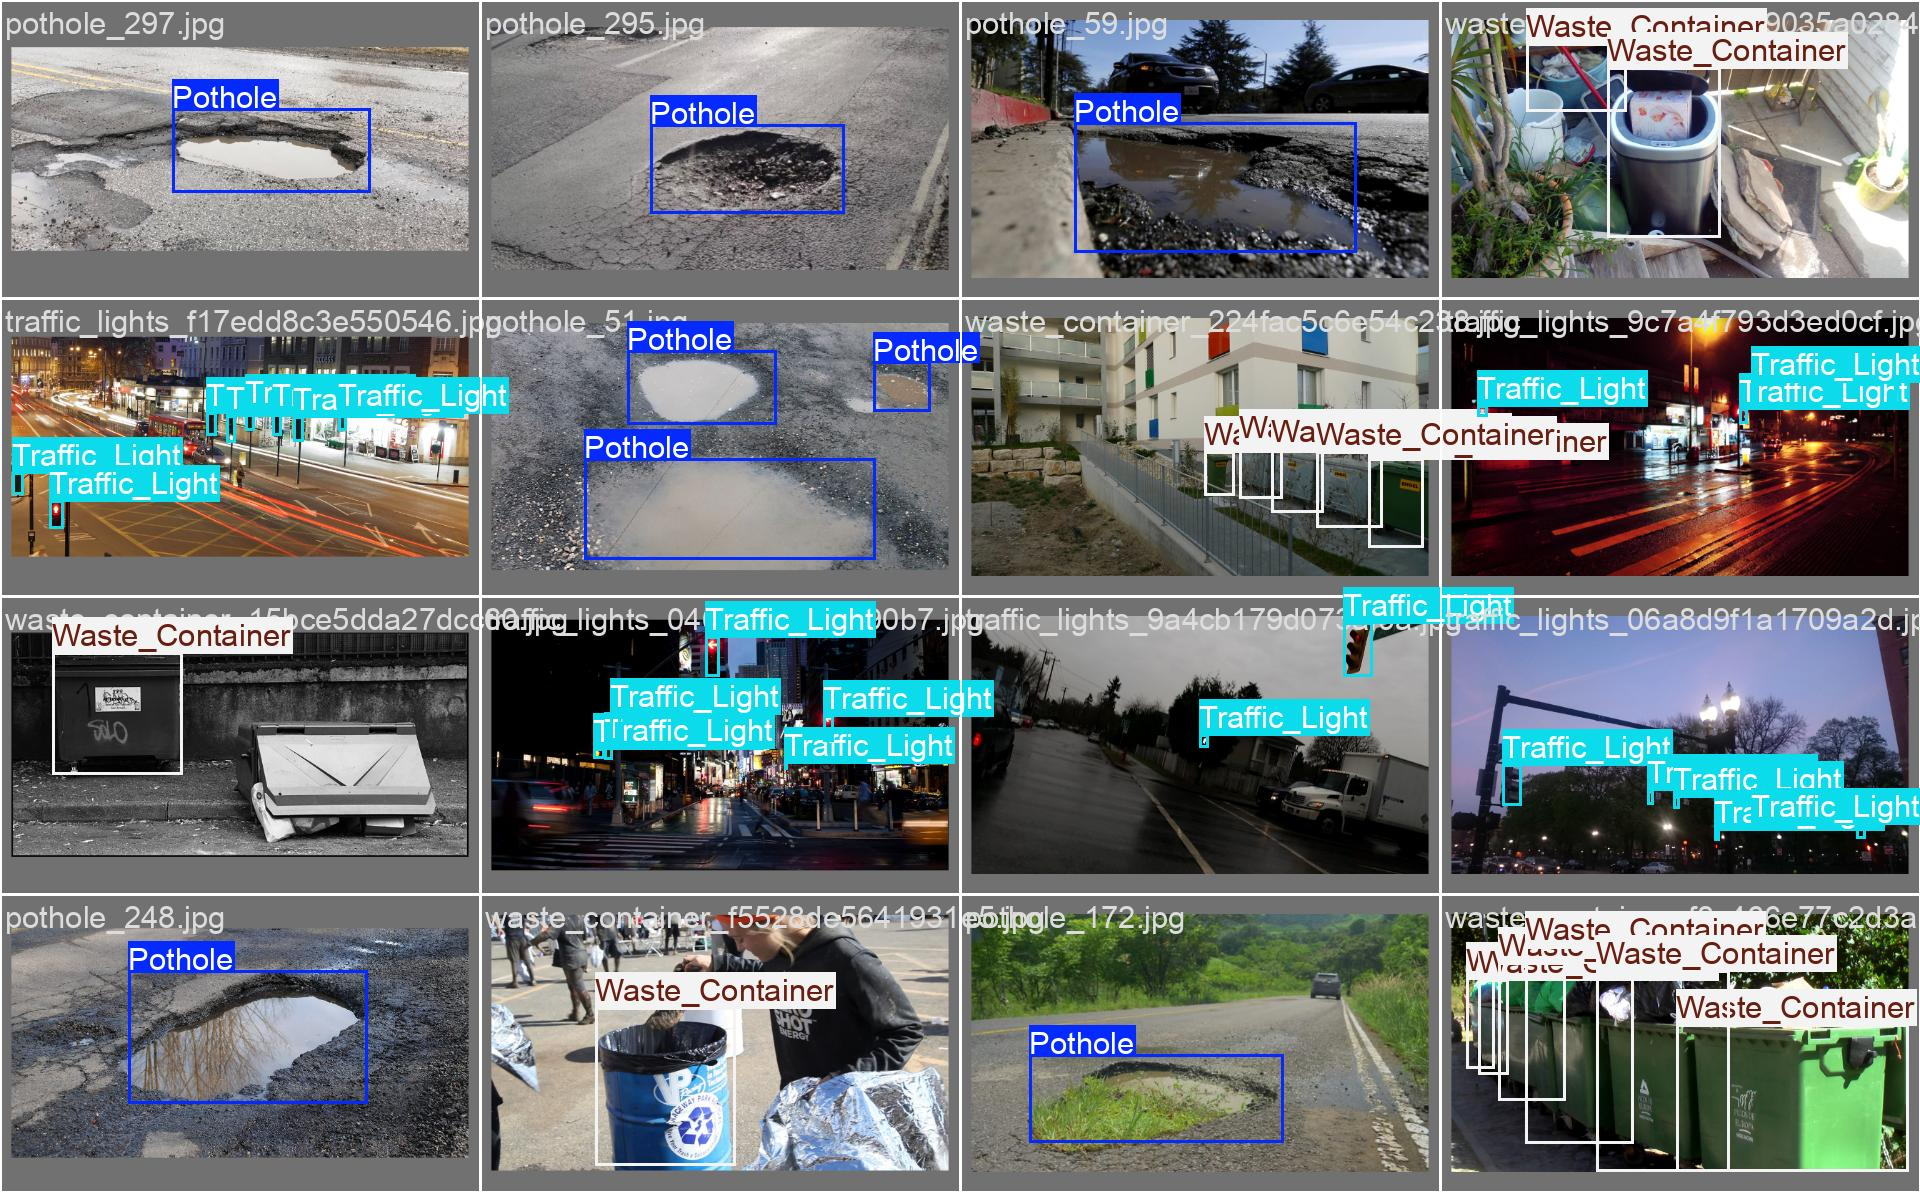

In [6]:
from IPython.display import Image, display
display(Image('runs/detect/smart_city_final/confusion_matrix.png'))
display(Image('runs/detect/smart_city_final/results.png'))
display(Image('runs/detect/smart_city_final/val_batch0_labels.jpg'))

In [9]:
# 5. Validation metrics
metrics = model.val()
print(f'mAP50:    {metrics.box.map50:.3f}')
print(f'mAP50-95: {metrics.box.map:.3f}')
print(f'Precision: {metrics.box.mp:.3f}')
print(f'Recall:    {metrics.box.mr:.3f}')

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2737.3±1268.0 MB/s, size: 291.3 KB)
val: Scanning /content/yolo_ready/labels/valid.cache... 301 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 301/301 114.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.2it/s 8.5s
                   all        301        852       0.83      0.685       0.73      0.416
               Pothole         51         84      0.877      0.765      0.813      0.434
         Traffic_Light        125        521      0.771      0.542      0.587      0.311
       Waste_Container        125        247      0.841      0.749      0.791      0.504
Speed: 1.9ms preprocess, 18.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val
mAP50

In [10]:
# 6. Download trained model
from google.colab import files
files.download('runs/detect/smart_city_final/weights/best.pt')
files.download('runs/detect/smart_city_final/confusion_matrix.png')
files.download('runs/detect/smart_city_final/results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import os
print("Looking for trained model anywhere on Colab...")
print("="*60)
# Search the whole filesystem for best.pt files
for root, dirs, files in os.walk('/content'):
    for file in files:
        if file == 'best.pt':
            full_path = os.path.join(root, file)
            size_mb = os.path.getsize(full_path) / (1024*1024)
            print(f"✓ Found: {full_path} ({size_mb:.1f} MB)")
print("="*60)
print("\nWhat's in /content/:")
for item in os.listdir('/content'):
    print(f"  {item}")

Looking for trained model anywhere on Colab...
✓ Found: /content/runs/detect/smart_city_final/weights/best.pt (49.6 MB)

What's in /content/:
  .config
  yolo_ready
  yolov8m.pt
  yolo26n.pt
  drive
  runs
  sample_data


In [8]:
import os
from google.colab import files

output_dir = '/content/runs/detect/smart_city_final-2'

if not os.path.exists(output_dir):
    print(f"✗ ERROR: The output directory '{output_dir}' was not found. Please ensure the training cell (phphFdejjPa2) was run successfully and the runtime has not reset.")
else:
    try:
        files.download(f'{output_dir}/weights/best.pt')
        files.download(f'{output_dir}/confusion_matrix.png')
        files.download(f'{output_dir}/results.png')
    except FileNotFoundError as e:
        print(f"✗ ERROR: One or more files not found within '{output_dir}': {e}")

✗ ERROR: The output directory '/content/runs/detect/smart_city_final-2' was not found. Please ensure the training cell (phphFdejjPa2) was run successfully and the runtime has not reset.
